
=== Logistic Regression Summary (coef, OR, p, CI) ===
                 coef  odds_ratio  pvalue  ci_low  ci_high  or_ci_low  \
variable                                                                
const          0.7155      2.0452  0.0000  0.4572   0.9738     1.5796   
age            0.0006      1.0006  0.5636 -0.0015   0.0027     0.9985   
educ           0.0505      1.0518  0.0000  0.0307   0.0704     1.0311   
ideology      -0.8257      0.4379  0.0000 -0.8633  -0.7881     0.4218   
sci_consensus  0.8564      2.3546  0.0000  0.8250   0.8877     2.2820   

               or_ci_high  
variable                   
const              2.6479  
age                1.0027  
educ               1.0730  
ideology           0.4547  
sci_consensus      2.4296  

Accuracy (test) = 0.776 | AUC (test) = 0.834
Confusion matrix (rows=true, cols=pred):
 [[1911 1131]
 [1043 5635]]

McFadden R² = 0.264 | Nagelkerke R² = 0.393


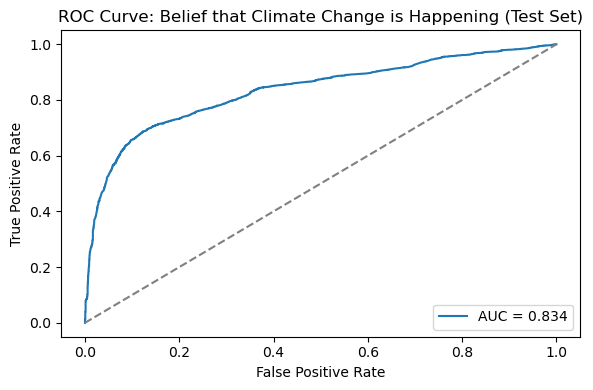

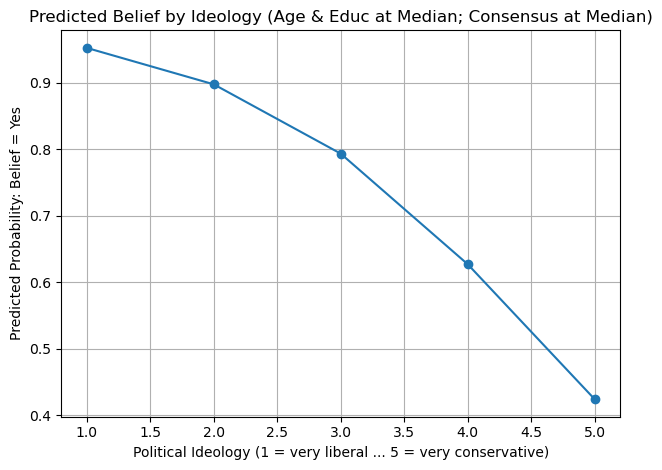


✅ Model results saved to: /Users/manikantarena/Downloads/model_results.xlsx


In [3]:
# =====================================================
# Logistic Regression: Belief in Climate Change (Yes=1 vs No/Not sure=0)
# Predictors: age, educ, ideology, sci_consensus
# =====================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from pathlib import Path

# ------------------ 1) Load and clean data ------------------
IN_PATH = Path("/Users/manikantarena/Downloads/climate_survey_cleaned.xlsx")  # update if needed
df = pd.read_excel(IN_PATH)

# Keep only required columns
req = ["happening", "age", "educ", "ideology", "sci_consensus"]
df = df[req].copy()

# Convert numeric columns safely
for c in req:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=req)

# Convert 'happening' into binary: 1 = believes climate change is happening, 0 = otherwise
df["happening"] = np.where(df["happening"] == df["happening"].max(), 1, 0)

# Round ideology & sci_consensus to remove decimals
df["ideology"] = df["ideology"].round(0).astype(int)
df["sci_consensus"] = df["sci_consensus"].round(0).astype(int)

# ------------------ 2) Prepare variables ------------------
y = df["happening"].astype(int)
X = df[["age", "educ", "ideology", "sci_consensus"]].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ------------------ 3) Fit logistic regression ------------------
X_train_sm = sm.add_constant(X_train, has_constant='add')
X_test_sm = sm.add_constant(X_test, has_constant='add')

logit_model = sm.Logit(y_train, X_train_sm)
res = logit_model.fit(disp=False)

# ------------------ 4) Model summary ------------------
coef = res.params.rename("coef")
pval = res.pvalues.rename("pvalue")
conf = res.conf_int(); conf.columns = ["ci_low", "ci_high"]
odds = np.exp(coef).rename("odds_ratio")
or_ci_low  = np.exp(conf["ci_low"]).rename("or_ci_low")
or_ci_high = np.exp(conf["ci_high"]).rename("or_ci_high")

summary_table = pd.concat([coef, odds, pval, conf, or_ci_low, or_ci_high], axis=1)
summary_table.index.name = "variable"

print("\n=== Logistic Regression Summary (coef, OR, p, CI) ===")
print(summary_table.round(4))

# ------------------ 5) Evaluate model performance ------------------
y_prob = res.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy (test) = {acc:.3f} | AUC (test) = {auc:.3f}")
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Calculate pseudo-R²
llf = res.llf
llnull = res.llnull
mcfadden_r2 = 1 - (llf / llnull)
nagelkerke_r2 = (1 - np.exp((2/len(y_train))*(llnull - llf))) / (1 - np.exp(2*llnull/len(y_train)))
print(f"\nMcFadden R² = {mcfadden_r2:.3f} | Nagelkerke R² = {nagelkerke_r2:.3f}")

# ------------------ 6) ROC Curve ------------------
fpr, tpr, thr = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Belief that Climate Change is Happening (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ------------------ 7) Predicted Probability vs Ideology ------------------
age_med = X["age"].median()
educ_med = X["educ"].median()
sci_med = int(round(X["sci_consensus"].median()))
sci_med = min(4, max(1, sci_med))  # keep within 1–4

ide_min = int(max(1, X["ideology"].min()))
ide_max = int(min(5, X["ideology"].max()))
ide_vals = np.arange(ide_min, ide_max + 1)

pred_grid = pd.DataFrame({
    "const": 1.0,
    "age": age_med,
    "educ": educ_med,
    "ideology": ide_vals,
    "sci_consensus": sci_med
})
pred_probs = res.predict(pred_grid)
pred_df = pd.DataFrame({"ideology": ide_vals, "pred_prob": pred_probs})

plt.figure()
plt.plot(pred_df["ideology"], pred_df["pred_prob"], marker="o")
plt.xlabel("Political Ideology (1 = very liberal ... 5 = very conservative)")
plt.ylabel("Predicted Probability: Belief = Yes")
plt.title("Predicted Belief by Ideology (Age & Educ at Median; Consensus at Median)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------ 8) Save Results to Excel ------------------
OUT_PATH = Path("/Users/manikantarena/Downloads/model_results.xlsx")
with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="cleaned_data", index=False)
    summary_table.to_excel(writer, sheet_name="logit_summary")
    pred_df.to_excel(writer, sheet_name="predicted_probs", index=False)

print(f"\n✅ Model results saved to: {OUT_PATH}")


